## Predicting Loan Payback.
    * Predicting the probabilty of a Loan Payback.
    * Implemented using XGBOOST
    * Categorical Values convertet to 1 and 0 using One Hot 
    * Training set split into Train and validation
    * Test Used for predicting real time predictions along with prability score
    
   

In [1]:
import numpy as np
import pandas as pd
import warnings
import datetime
import xgboost as xgb
import seaborn as sns
import itertools
import datetime
import sys
import os
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GridSearchCV
%matplotlib inline
warnings.filterwarnings("ignore")




In [128]:
# Load the Training dataset for Bank Loan Dataset
MyData = pd.read_csv(r'..\..\data\kaggle_bankloan_train.csv') 
MyData.shape


(593994, 13)

In [129]:
MyData.head(7)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1
5,5,44940.30,0.058,653,12159.92,12.24,Male,Single,Bachelor's,Employed,Other,D1,1
6,6,61574.16,0.042,696,16907.71,13.52,Other,Single,High School,Self-employed,Debt consolidation,C5,1


In [130]:
MyData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  int64  
dtypes: float64(4), int64(3), object(6)
memory usage: 58.9+ MB


In [131]:
MyData.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,296996.500000,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,171471.442235,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,0.000000,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,148498.250000,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,296996.500000,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,445494.750000,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,593993.000000,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [132]:
MyData.columns

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade', 'loan_paid_back'],
      dtype='object')

In [133]:
MyData.head(5)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1


In [134]:
# Approach 3: One-hot encoding
dummy_columns = ["loan_purpose","gender","marital_status","education_level","employment_status","grade_subgrade"]
MyData_ohe = pd.get_dummies(MyData, columns=dummy_columns, dtype=int)
#X_test_ohe  = pd.get_dummies(X_test, columns=dummy_columns)
MyData_ohe.head(5)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,0,29367.99,0.084,736,2528.42,13.67,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,22108.02,0.166,636,4593.10,12.92,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,2,49566.20,0.097,694,17005.15,9.76,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
3,3,46858.25,0.065,533,4682.48,16.10,1,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,4,25496.70,0.053,665,12184.43,10.21,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [135]:
MyData_ohe.columns 

Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'loan_paid_back',
       'loan_purpose_Business', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation', 'gender_Female', 'gender_Male', 'gender_Other',
       'marital_status_Divorced', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_Bachelor's', 'education_level_High School',
       'education_level_Master's', 'education_level_Other',
       'education_level_PhD', 'employment_status_Employed',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'grade_subgrade_A1', 'grade_subgrade_A2', 'grade_subgrade_A3',
       'grade_subgrade_A4', 'grade_subgrade_A5', 'grade_subgrade_B1',
       'grade_

In [136]:
columns_rearranged = ['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 
       'loan_purpose_Business', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation', 'gender_Female', 'gender_Male', 'gender_Other',
       'marital_status_Divorced', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_Bachelor\'s', 'education_level_High School',
       'education_level_Master\'s', 'education_level_Other',
       'education_level_PhD', 'employment_status_Employed',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'grade_subgrade_A1', 'grade_subgrade_A2', 'grade_subgrade_A3',
       'grade_subgrade_A4', 'grade_subgrade_A5', 'grade_subgrade_B1',
       'grade_subgrade_B2', 'grade_subgrade_B3', 'grade_subgrade_B4',
       'grade_subgrade_B5', 'grade_subgrade_C1', 'grade_subgrade_C2',
       'grade_subgrade_C3', 'grade_subgrade_C4', 'grade_subgrade_C5',
       'grade_subgrade_D1', 'grade_subgrade_D2', 'grade_subgrade_D3',
       'grade_subgrade_D4', 'grade_subgrade_D5', 'grade_subgrade_E1',
       'grade_subgrade_E2', 'grade_subgrade_E3', 'grade_subgrade_E4',
       'grade_subgrade_E5', 'grade_subgrade_F1', 'grade_subgrade_F2',
       'grade_subgrade_F3', 'grade_subgrade_F4', 'grade_subgrade_F5','loan_paid_back']
MyData_ohe = MyData_ohe[columns_rearranged]
MyData_ohe.head(5)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,...,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,22108.02,0.166,636,4593.10,12.92,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2,49566.20,0.097,694,17005.15,9.76,0,0,1,0,...,0,0,0,0,0,0,0,0,0,1
3,3,46858.25,0.065,533,4682.48,16.10,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
4,4,25496.70,0.053,665,12184.43,10.21,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


In [137]:
columns_to_select = ['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 
       'loan_purpose_Business', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation', 'gender_Female', 'gender_Male', 'gender_Other',
       'marital_status_Divorced', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_Bachelor\'s', 'education_level_High School',
       'education_level_Master\'s', 'education_level_Other',
       'education_level_PhD', 'employment_status_Employed',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'grade_subgrade_A1', 'grade_subgrade_A2', 'grade_subgrade_A3',
       'grade_subgrade_A4', 'grade_subgrade_A5', 'grade_subgrade_B1',
       'grade_subgrade_B2', 'grade_subgrade_B3', 'grade_subgrade_B4',
       'grade_subgrade_B5', 'grade_subgrade_C1', 'grade_subgrade_C2',
       'grade_subgrade_C3', 'grade_subgrade_C4', 'grade_subgrade_C5',
       'grade_subgrade_D1', 'grade_subgrade_D2', 'grade_subgrade_D3',
       'grade_subgrade_D4', 'grade_subgrade_D5', 'grade_subgrade_E1',
       'grade_subgrade_E2', 'grade_subgrade_E3', 'grade_subgrade_E4',
       'grade_subgrade_E5', 'grade_subgrade_F1', 'grade_subgrade_F2',
       'grade_subgrade_F3', 'grade_subgrade_F4', 'grade_subgrade_F5']

X_train_ohe = MyData_ohe[columns_to_select]
y_train_ohe = MyData_ohe['loan_paid_back']
X_train_ohe.head(5)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,0,29367.99,0.084,736,2528.42,13.67,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,1,22108.02,0.166,636,4593.10,12.92,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,2,49566.20,0.097,694,17005.15,9.76,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,3,46858.25,0.065,533,4682.48,16.10,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
4,4,25496.70,0.053,665,12184.43,10.21,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [138]:
y_train_ohe.head(5)

0    1
1    0
2    1
3    1
4    1
Name: loan_paid_back, dtype: int64

In [139]:
# With random_state for reproducibility and shuffle=True (default)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_ohe, 
    y_train_ohe, 
    test_size=0.2, 
    random_state=42,  # For reproducibility
    shuffle=True       # Shuffle data before splitting (default is True)
)
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)
print("Train:", len(X_train))  # Changed 'length' to 'len' which is the correct Python function to get length

(475195, 61) (475195,)
(118799, 61) (118799,)
Train: 475195


In [140]:
X_train.head(5)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
119010,119010,17165.69,0.071,719,19154.78,9.31,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
165500,165500,87929.11,0.071,728,7367.61,11.94,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
290800,290800,37254.01,0.080,654,2672.78,12.52,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
184308,184308,25863.67,0.068,732,10703.41,10.71,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
137347,137347,153072.69,0.090,668,7782.41,10.59,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


In [141]:
independent_variables = [ 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 
       'loan_purpose_Business', 'loan_purpose_Car',
       'loan_purpose_Debt consolidation', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Other',
       'loan_purpose_Vacation', 'gender_Female', 'gender_Male', 'gender_Other',
       'marital_status_Divorced', 'marital_status_Married',
       'marital_status_Single', 'marital_status_Widowed',
       'education_level_Bachelor\'s', 'education_level_High School',
       'education_level_Master\'s', 'education_level_Other',
       'education_level_PhD', 'employment_status_Employed',
       'employment_status_Retired', 'employment_status_Self-employed',
       'employment_status_Student', 'employment_status_Unemployed',
       'grade_subgrade_A1', 'grade_subgrade_A2', 'grade_subgrade_A3',
       'grade_subgrade_A4', 'grade_subgrade_A5', 'grade_subgrade_B1',
       'grade_subgrade_B2', 'grade_subgrade_B3', 'grade_subgrade_B4',
       'grade_subgrade_B5', 'grade_subgrade_C1', 'grade_subgrade_C2',
       'grade_subgrade_C3', 'grade_subgrade_C4', 'grade_subgrade_C5',
       'grade_subgrade_D1', 'grade_subgrade_D2', 'grade_subgrade_D3',
       'grade_subgrade_D4', 'grade_subgrade_D5', 'grade_subgrade_E1',
       'grade_subgrade_E2', 'grade_subgrade_E3', 'grade_subgrade_E4',
       'grade_subgrade_E5', 'grade_subgrade_F1', 'grade_subgrade_F2',
       'grade_subgrade_F3', 'grade_subgrade_F4', 'grade_subgrade_F5']

X_train_fit = X_train[independent_variables]
X_val_fit   = X_val[independent_variables]
X_train_fit.head(5)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
119010,17165.69,0.071,719,19154.78,9.31,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
165500,87929.11,0.071,728,7367.61,11.94,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
290800,37254.01,0.080,654,2672.78,12.52,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
184308,25863.67,0.068,732,10703.41,10.71,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
137347,153072.69,0.090,668,7782.41,10.59,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [142]:
X_val_fit.head(5)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
404674,52470.61,0.241,724,27172.82,13.35,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
549728,28424.82,0.033,779,15895.96,11.57,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
125237,25229.55,0.195,569,15216.06,13.83,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
512666,91612.58,0.166,659,13166.90,12.47,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
101001,79712.79,0.079,767,23642.37,11.23,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [143]:
# Launch a classifier
# XGBoost Training Parameter Reference: 
#   https://xgboost.readthedocs.io/en/latest/parameter.html
classifier = xgb.XGBClassifier(objective="binary:logistic",
                               eval_metric=['logloss'],
                               enable_categorical=True,
                               early_stopping_rounds=10)

In [144]:
classifier

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=True, eval_metric=['logloss'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [145]:
classifier.fit(X_train_fit,
               y_train, 
               eval_set = [(X_train_fit, y_train), (X_val_fit, y_val)])

[0]	validation_0-logloss:0.37126	validation_1-logloss:0.37206
[1]	validation_0-logloss:0.32781	validation_1-logloss:0.32846
[2]	validation_0-logloss:0.30221	validation_1-logloss:0.30272
[3]	validation_0-logloss:0.28587	validation_1-logloss:0.28635
[4]	validation_0-logloss:0.27517	validation_1-logloss:0.27568
[5]	validation_0-logloss:0.26806	validation_1-logloss:0.26864
[6]	validation_0-logloss:0.26319	validation_1-logloss:0.26386
[7]	validation_0-logloss:0.25983	validation_1-logloss:0.26060
[8]	validation_0-logloss:0.25750	validation_1-logloss:0.25841
[9]	validation_0-logloss:0.25589	validation_1-logloss:0.25684
[10]	validation_0-logloss:0.25477	validation_1-logloss:0.25579
[11]	validation_0-logloss:0.25392	validation_1-logloss:0.25506
[12]	validation_0-logloss:0.25334	validation_1-logloss:0.25458
[13]	validation_0-logloss:0.25284	validation_1-logloss:0.25424
[14]	validation_0-logloss:0.25253	validation_1-logloss:0.25402
[15]	validation_0-logloss:0.25149	validation_1-logloss:0.25324
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=True, eval_metric=['logloss'],
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [146]:
eval_result = classifier.evals_result()

In [147]:
training_rounds = range(len(eval_result['validation_0']['logloss']))

In [148]:
print(training_rounds)

range(0, 84)


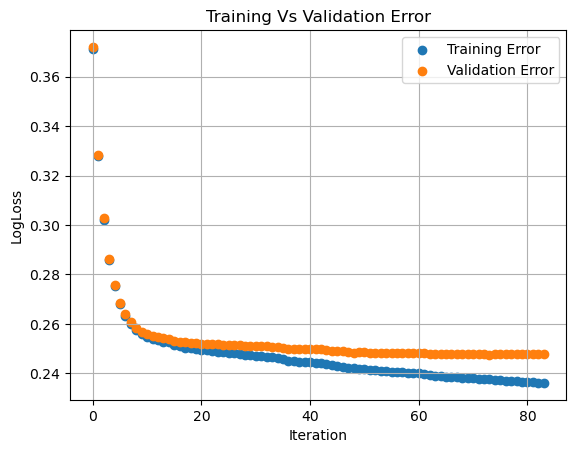

In [149]:
plt.scatter(x=training_rounds,y=eval_result['validation_0']['logloss'],label='Training Error')
plt.scatter(x=training_rounds,y=eval_result['validation_1']['logloss'],label='Validation Error')
plt.grid(True)
plt.xlabel('Iteration')
plt.ylabel('LogLoss')
plt.title('Training Vs Validation Error')
plt.legend()
plt.show()

In [150]:
y_pred = classifier.predict(X_val_fit)

Accuracy: 0.9044
Accuracy: 90.44%
Accuracy (from confusion matrix): 0.9044
Accuracy (from confusion matrix): 90.44%


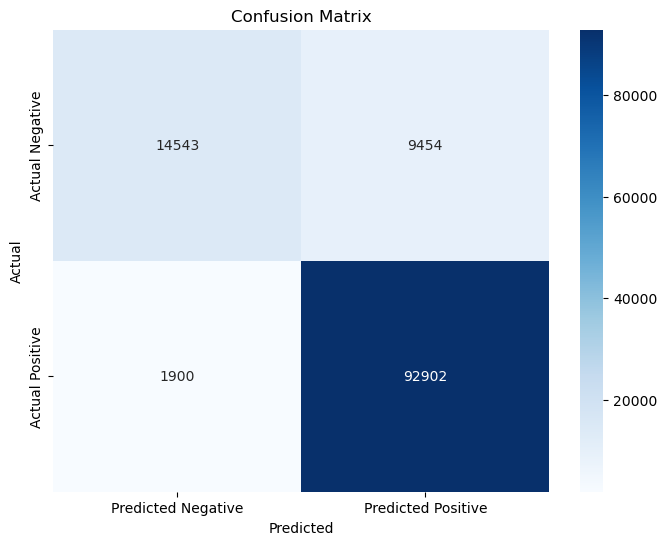

In [151]:
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Get confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Calculate accuracy manually from confusion matrix
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    accuracy_from_cm = (tp + tn) / (tp + tn + fp + fn)
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm:.4f}")
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm*100:.2f}%")

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# For multi-class problems, you might want to normalize the confusion matrix
if cm.shape[0] > 2:
    # Normalize the confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    # Plot normalized confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues')
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.title('Normalized Confusion Matrix')
    plt.show()

In [152]:
# Calculate accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print(f"Accuracy: {accuracy*100:.2f}%")

# Alternative method using confusion matrix
from sklearn.metrics import confusion_matrix

# Get confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Calculate accuracy manually from confusion matrix
# For binary classification:
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    accuracy_from_cm = (tp + tn) / (tp + tn + fp + fn)
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm:.4f}")
    print(f"Accuracy (from confusion matrix): {accuracy_from_cm*100:.2f}%")

Accuracy: 0.9044
Accuracy: 90.44%
Accuracy (from confusion matrix): 0.9044
Accuracy (from confusion matrix): 90.44%


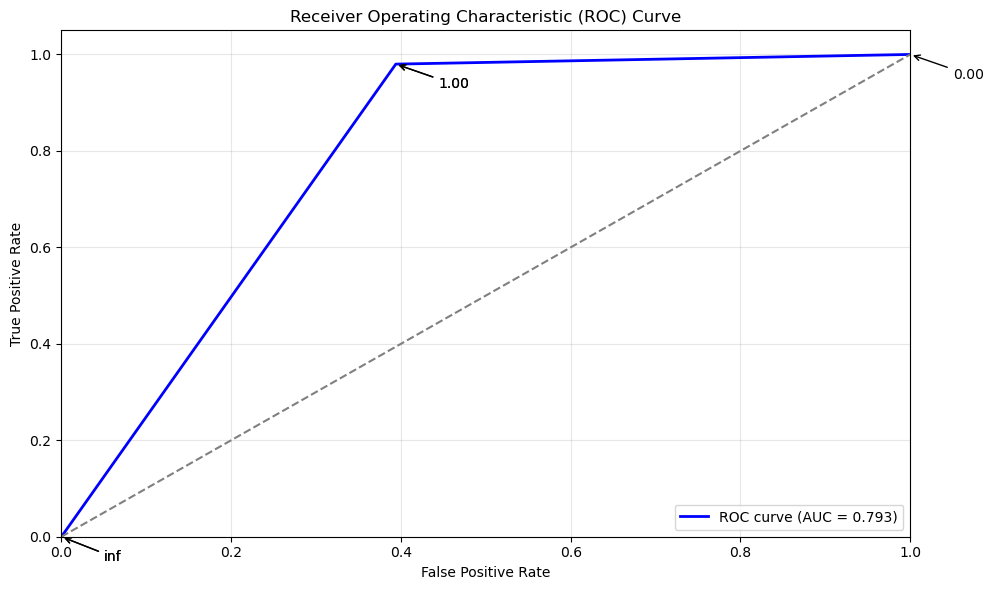

AUC: 0.7930


In [153]:
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get predicted probabilities for the positive class
# For binary classification, we need the probability of the positive class (class 1)
# y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]

# Calculate ROC curve points
fpr, tpr, thresholds = roc_curve(y_val, y_pred)

# Calculate AUC
roc_auc = auc(fpr, tpr)
# Alternative: roc_auc = roc_auc_score(y_test, y_pred_proba)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal line (random classifier)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Add some threshold annotations
# Select a few thresholds to annotate
threshold_indices = np.linspace(0, len(thresholds) - 1, 5, dtype=int)
for i in threshold_indices:
    plt.annotate(f'{thresholds[i]:.2f}', 
                 xy=(fpr[i], tpr[i]), 
                 xytext=(fpr[i]+0.05, tpr[i]-0.05),
                 arrowprops=dict(arrowstyle='->', connectionstyle='arc3'))

plt.tight_layout()
plt.show()

# Print AUC value
print(f"AUC: {roc_auc:.4f}")

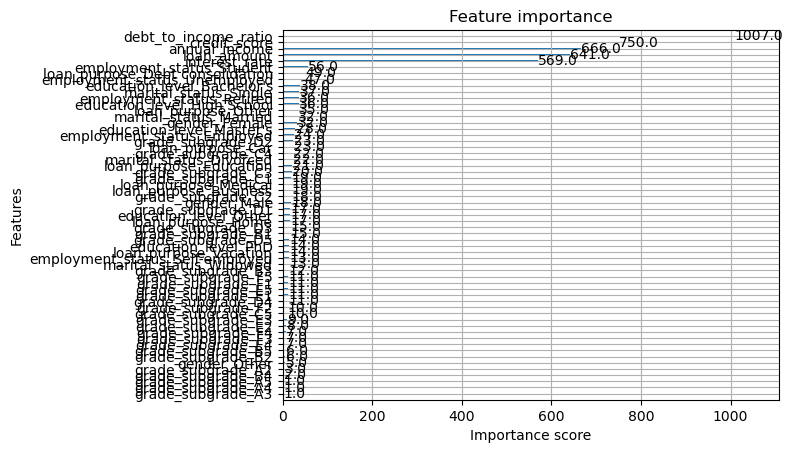

In [154]:
xgb.plot_importance(classifier)
plt.show()

In [2]:
# Get feature importance as a dictionary
feature_importance = classifier.get_booster().get_score(importance_type='weight')

# Convert to a more readable format (sorted by importance)
import pandas as pd

# Create a DataFrame for better display
importance_df = pd.DataFrame({
    'Feature': list(feature_importance.keys()),
    'Importance': list(feature_importance.values())
})

# Sort by importance in descending order
importance_df = importance_df.sort_values('Importance', ascending=False)

# Display the feature importance
print(importance_df)

NameError: name 'classifier' is not defined

In [155]:
probabilities = classifier.predict_proba(X_val_fit)

In [156]:
val_probabilities_df = pd.DataFrame({
    'id': X_val['id'].reset_index(drop=True),
    # Extract the probability for class 1 (second column)
    'y': pd.Series(probabilities[:, 1]).reset_index(drop=True)  # Using column index 1 for positive class probability
    # Alternatively, if you want both probabilities:
    # 'y_class0': pd.Series(probabilities[:, 0]).reset_index(drop=True),
    # 'y_class1': pd.Series(probabilities[:, 1]).reset_index(drop=True)
})
val_probabilities_df.head(10)

,id,y
0,404674,0.841314
1,549728,0.999204
2,125237,0.338525
3,512666,0.804990
4,101001,0.995424
5,331529,0.887361
6,260774,0.998052
7,138870,0.738433
8,585176,0.839145
9,466795,0.987803


In [157]:
# Load the test dataset for Bank Dataset
MyData_test = pd.read_csv(r'..\..\data\kaggle_bankloan_test.csv') 
MyData_test.shape

(254569, 12)

In [158]:
MyData_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254569 entries, 0 to 254568
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    254569 non-null  int64  
 1   annual_income         254569 non-null  float64
 2   debt_to_income_ratio  254569 non-null  float64
 3   credit_score          254569 non-null  int64  
 4   loan_amount           254569 non-null  float64
 5   interest_rate         254569 non-null  float64
 6   gender                254569 non-null  object 
 7   marital_status        254569 non-null  object 
 8   education_level       254569 non-null  object 
 9   employment_status     254569 non-null  object 
 10  loan_purpose          254569 non-null  object 
 11  grade_subgrade        254569 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 23.3+ MB


In [159]:
MyData_test.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate
count,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000
mean,721278.000000,48233.080193,0.120583,681.037691,15016.753484,12.352323
std,73487.884676,26719.658580,0.068582,55.624118,6922.165182,2.017602
min,593994.000000,6011.770000,0.011000,395.000000,500.050000,3.200000
25%,657636.000000,27950.300000,0.072000,646.000000,10248.580000,10.980000
50%,721278.000000,46528.980000,0.096000,683.000000,15000.220000,12.370000
75%,784920.000000,61149.440000,0.156000,719.000000,18831.460000,13.690000
max,848562.000000,380653.940000,0.627000,849.000000,48959.260000,21.290000


In [160]:
MyData_test.columns


Index(['id', 'annual_income', 'debt_to_income_ratio', 'credit_score',
       'loan_amount', 'interest_rate', 'gender', 'marital_status',
       'education_level', 'employment_status', 'loan_purpose',
       'grade_subgrade'],
      dtype='object')

In [161]:
# Approach 3: One-hot encoding
dummy_columns = ["loan_purpose","gender","marital_status","education_level","employment_status","grade_subgrade"]
MyData_test_ohe = pd.get_dummies(MyData_test, columns=dummy_columns, dtype=int)
#X_test_ohe  = pd.get_dummies(X_test, columns=dummy_columns)
MyData_test_ohe.head(5)


,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,593994,28781.05,0.049,626,11461.42,14.73,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,593995,46626.39,0.093,732,15492.25,12.85,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,593996,54954.89,0.367,611,3796.41,13.29,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,593997,25644.63,0.110,671,6574.30,9.57,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,593998,25169.64,0.081,688,17696.89,12.80,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [162]:
MyData_test_ohe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254569 entries, 0 to 254568
Data columns (total 61 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   id                               254569 non-null  int64  
 1   annual_income                    254569 non-null  float64
 2   debt_to_income_ratio             254569 non-null  float64
 3   credit_score                     254569 non-null  int64  
 4   loan_amount                      254569 non-null  float64
 5   interest_rate                    254569 non-null  float64
 6   loan_purpose_Business            254569 non-null  int64  
 7   loan_purpose_Car                 254569 non-null  int64  
 8   loan_purpose_Debt consolidation  254569 non-null  int64  
 9   loan_purpose_Education           254569 non-null  int64  
 10  loan_purpose_Home                254569 non-null  int64  
 11  loan_purpose_Medical             254569 non-null  int64  
 12  lo

In [163]:
MyData_test_ohe.head(5)

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,593994,28781.05,0.049,626,11461.42,14.73,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,593995,46626.39,0.093,732,15492.25,12.85,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,593996,54954.89,0.367,611,3796.41,13.29,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,593997,25644.63,0.110,671,6574.30,9.57,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,593998,25169.64,0.081,688,17696.89,12.80,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [164]:
X_test_ohe_fit = MyData_test_ohe[independent_variables]
X_test_ohe_fit.head(5)

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,loan_purpose_Home,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
0,28781.05,0.049,626,11461.42,14.73,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,46626.39,0.093,732,15492.25,12.85,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,54954.89,0.367,611,3796.41,13.29,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,25644.63,0.110,671,6574.30,9.57,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,25169.64,0.081,688,17696.89,12.80,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [165]:
y_pred_test = classifier.predict(X_test_ohe_fit)

In [166]:
submission_df = pd.DataFrame({
    'id': MyData_test_ohe['id'].reset_index(drop=True),
    'y': pd.Series(y_pred_test).reset_index(drop=True)
})

In [167]:
submission_df.head(5)

,id,y
0,593994,1
1,593995,1
2,593996,0
3,593997,1
4,593998,1


In [168]:
# Count distinct values in column Y
distinct_count = submission_df['y'].value_counts()
print(distinct_count)

# If you just want the number of distinct values
num_distinct = submission_df['y'].nunique()
print(f"Number of distinct values: {num_distinct}")

y
1    219573
0     34996
Name: count, dtype: int64
Number of distinct values: 2


In [169]:
test_probabilities = classifier.predict_proba(X_test_ohe_fit)


In [170]:
submission_probabilities_df = pd.DataFrame({
    'id': MyData_test_ohe['id'].reset_index(drop=True),
    # Extract the probability for class 1 (second column)
    'y': pd.Series(test_probabilities[:, 1]).reset_index(drop=True)  # Using column index 1 for positive class probability
    # Alternatively, if you want both probabilities:
    # 'y_class0': pd.Series(probabilities[:, 0]).reset_index(drop=True),
    # 'y_class1': pd.Series(probabilities[:, 1]).reset_index(drop=True)
})
submission_probabilities_df.head(10)

,id,y
0,593994,0.927377
1,593995,0.985761
2,593996,0.451029
3,593997,0.918582
4,593998,0.957360
5,593999,0.970130
6,594000,0.986090
7,594001,0.975158
8,594002,0.936528
9,594003,0.002397


In [171]:
MyData_test_ohe.describe()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_purpose_Business,loan_purpose_Car,loan_purpose_Debt consolidation,loan_purpose_Education,...,grade_subgrade_E1,grade_subgrade_E2,grade_subgrade_E3,grade_subgrade_E4,grade_subgrade_E5,grade_subgrade_F1,grade_subgrade_F2,grade_subgrade_F3,grade_subgrade_F4,grade_subgrade_F5
count,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,...,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000,254569.000000
mean,721278.000000,48233.080193,0.120583,681.037691,15016.753484,12.352323,0.059222,0.097769,0.545876,0.061748,...,0.011408,0.010736,0.012040,0.013321,0.010253,0.009117,0.008756,0.008642,0.009581,0.010064
std,73487.884676,26719.658580,0.068582,55.624118,6922.165182,2.017602,0.236040,0.297003,0.497892,0.240697,...,0.106195,0.103056,0.109064,0.114644,0.100735,0.095049,0.093163,0.092560,0.097412,0.099814
min,593994.000000,6011.770000,0.011000,395.000000,500.050000,3.200000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,657636.000000,27950.300000,0.072000,646.000000,10248.580000,10.980000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,721278.000000,46528.980000,0.096000,683.000000,15000.220000,12.370000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,784920.000000,61149.440000,0.156000,719.000000,18831.460000,13.690000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,848562.000000,380653.940000,0.627000,849.000000,48959.260000,21.290000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [172]:
submission_probabilities_df.describe()

,id,y
count,254569.000000,254569.000000
mean,721278.000000,0.799765
std,73487.884676,0.295902
min,593994.000000,0.000233
25%,657636.000000,0.798879
50%,721278.000000,0.931873
75%,784920.000000,0.978679
max,848562.000000,0.999945


In [173]:
submission_probabilities_df.to_csv(r'..\..\results\submission.csv', index=False)
print("CSV file has been created successfully!")

CSV file has been created successfully!


In [174]:
# Define the threshold as a variable
threshold = 0.5

# Filter the DataFrame to show only rows where y >= threshold
filtered_df = submission_probabilities_df[submission_probabilities_df['y'] >= threshold]

# Display all filtered rows
print(f"Rows where y >= {threshold}:")
display(filtered_df)

# Count the total number of rows where y >= threshold
count = len(filtered_df)
print(f"\nTotal number of rows where y >= {threshold}: {count}")

# Optional: Calculate the percentage of rows that meet the condition
percentage = (count / len(submission_probabilities_df)) * 100
print(f"Percentage of rows where y >= {threshold}: {percentage:.2f}%")

Rows where y >= 0.5:


,id,y
0,593994,0.927377
1,593995,0.985761
3,593997,0.918582
4,593998,0.957360
5,593999,0.970130
...,...,...
254564,848558,0.993735
254565,848559,0.830158
254566,848560,0.977197
254567,848561,0.986188



Total number of rows where y >= 0.5: 219573
Percentage of rows where y >= 0.5: 86.25%
